## Transformer入门到精通

引用论文：
- 论文地址："Attention is All You Need": https://arxiv.org/abs/1706.03762
- 论文地址："Neural Machine Translation by Jointly Learning to Align and Translate" https://arxiv.org/abs/1409.0473
- 论文地址："Generating Sequences With Recurrent Neural Networks" https://arxiv.org/abs/1308.0850
- 论文地址: "Deep Residual Learning for Image Recognition" https://arxiv.org/abs/1512.03385
- 论文地址："Layer Normalization" https://arxiv.org/abs/1607.06450
- 论文地址："Dropout: A Simple Way to Prevent Neural Networks from Overfitting" https://jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf
- 论文地址："Neural Machine Translation by Jointly Learning to Align and Translate" https://arxiv.org/abs/1409.0473
- 论文地址："Massive Exploration of Neural Machine Translation Architectures" https://arxiv.org/abs/1703.03906
- 论文地址："Google's Neural Machine Translation System: Bridging the Gap between Human and Machine Translation" https://arxiv.org/abs/1609.08144
- 论文地址："Using the Output Embedding to Improve Language Models" https://arxiv.org/abs/1608.05859
- 论文地址："Convolutional Sequence to Sequence Learning" https://arxiv.org/pdf/1705.03122
- 论文地址："Adam: A Method for Stochastic Optimization" https://arxiv.org/abs/1412.6980

### 参考资源
- Transformer代码注释版本：https://nlp.seas.harvard.edu/2018/04/03/attention.html
- Seq2Seq模型：https://jalammar.github.io/visualizing-neural-machine-translation-mechanics-of-seq2seq-models-with-attention/
- Transformer可视化版本：https://jalammar.github.io/illustrated-transformer/
- Transformer其他版本： https://www.cnblogs.com/shouhuxianjian/p/16165451.html

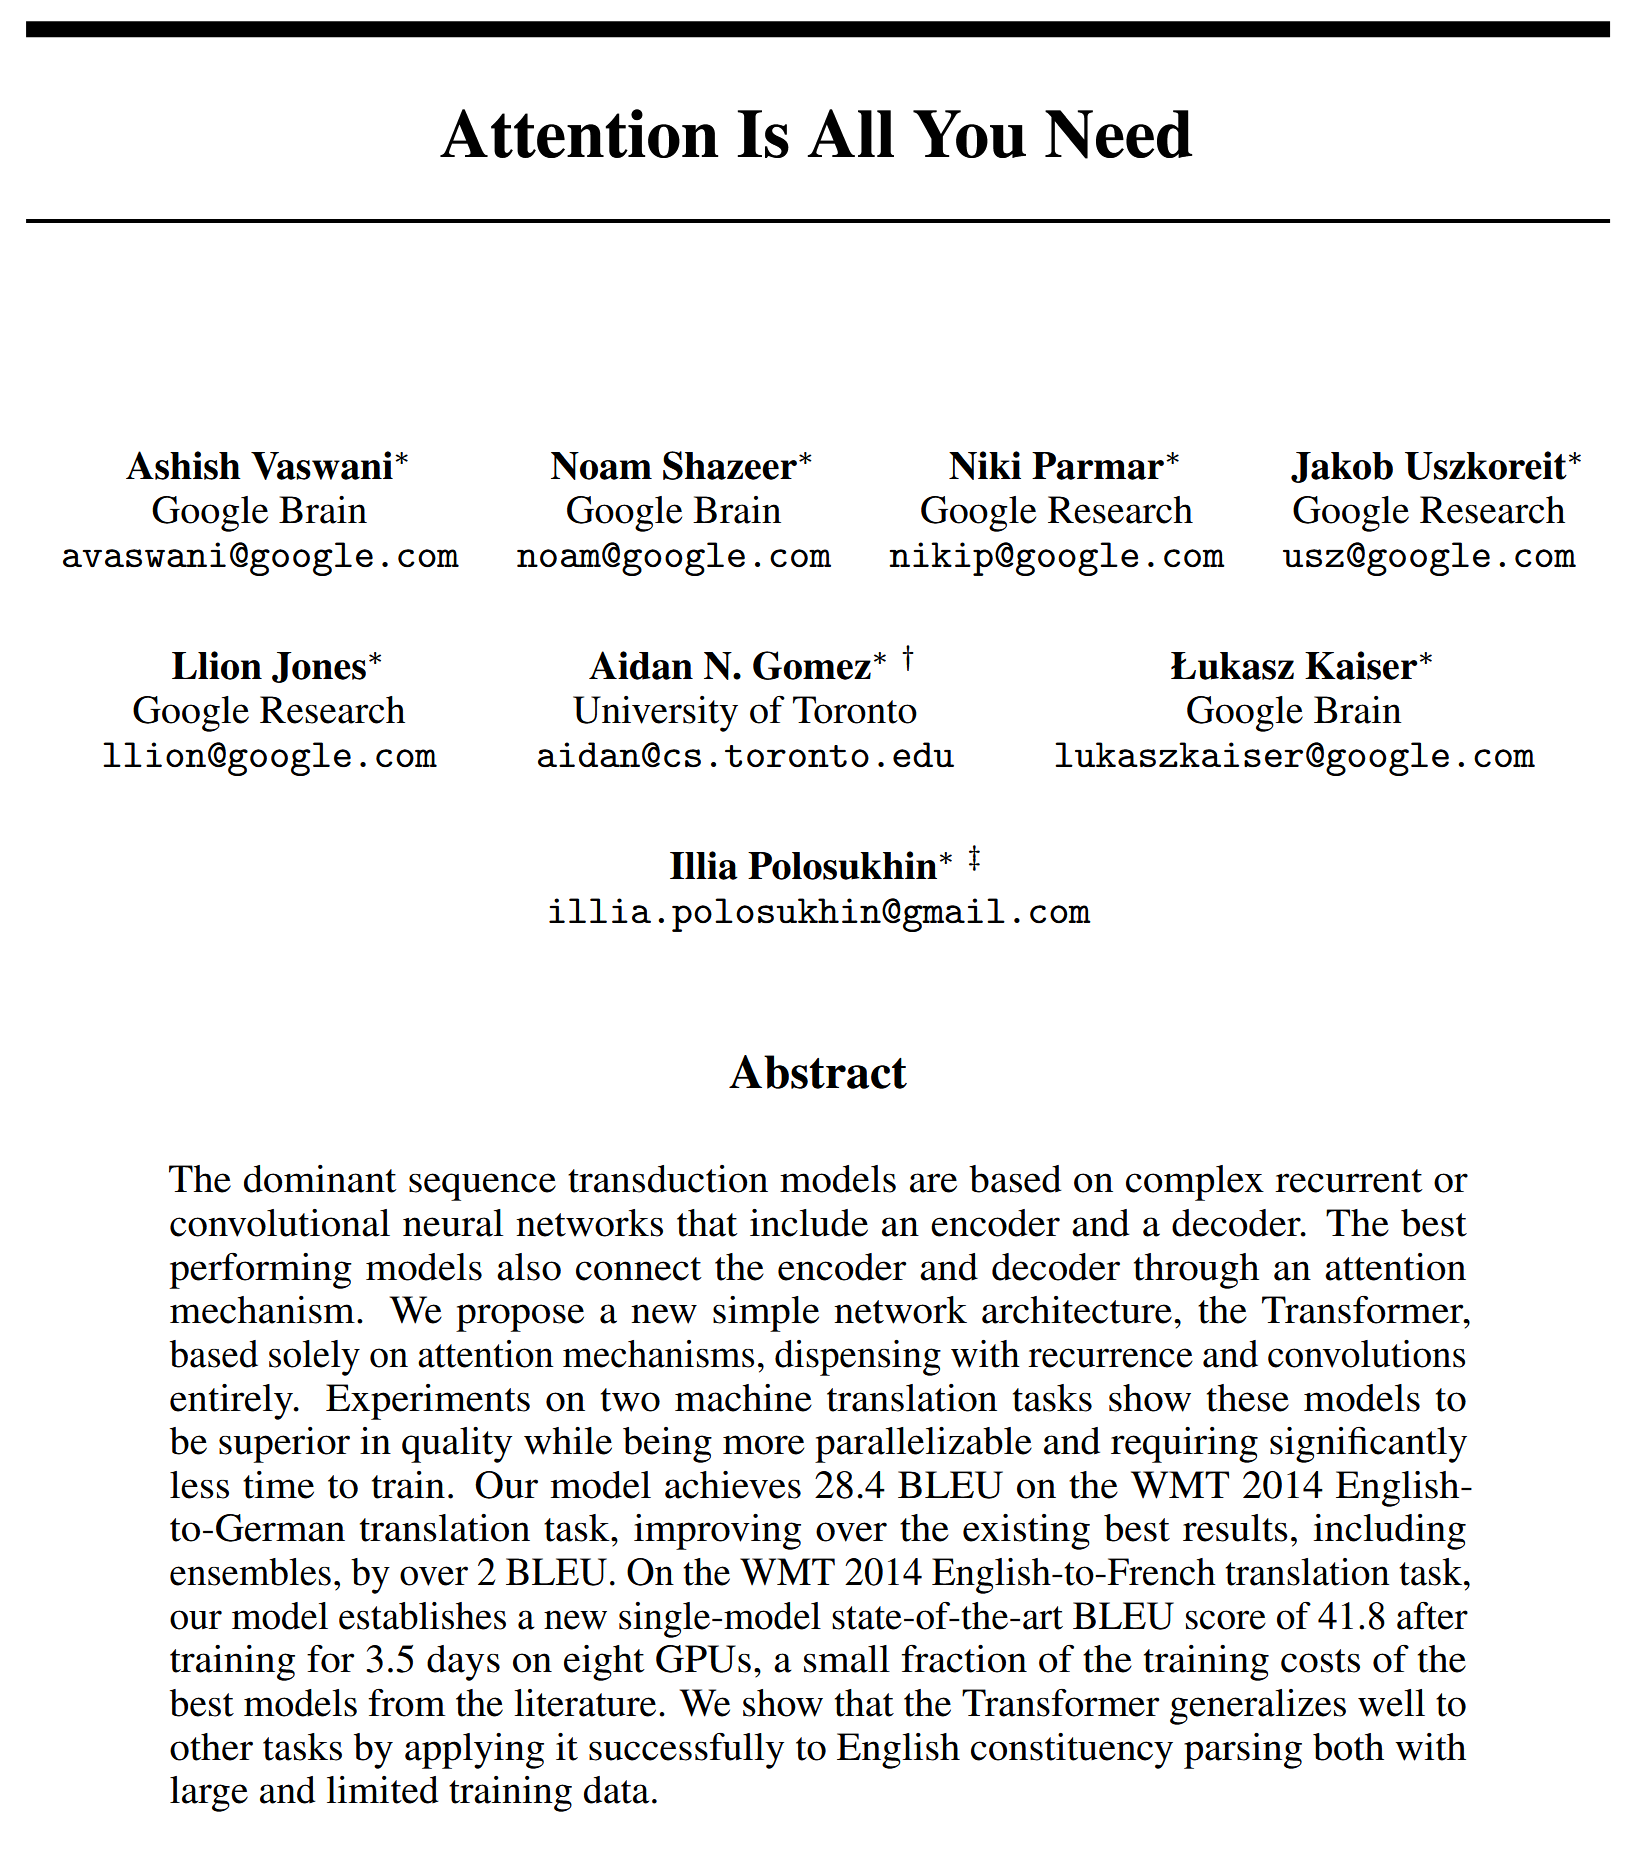

In [1]:
from IPython.display import Image
Image(filename='images/attention_is_all_you_need.png')

### 前言

在这篇文章中，以逐行实现的形式介绍了该论文的“注释”版本。重新排序并删除了原始论文中的一些部分，并在整个过程中添加了注释。
本文档本身是一个工作笔记本，应该是一个完全可用的实现。总共有 400 行库代码，可以在 4 个 GPU 上每秒处理 27,000 个令牌。

### 背景

减少顺序计算的目标也是扩展神经 GPU、ByteNet 和 ConvS2S 的基础，它们都使用卷积神经网络作为基本构建块，并行计算所有输入和输出位置的隐藏表示。在这些模型中，关联两个任意输入或输出位置的信号所需的操作数随着位置之间的距离而增加，对于 ConvS2S 呈线性增长，对于 ByteNet 呈对数增长。**这使得学习远距离位置之间的依赖关系变得更加困难**。


在 Transformer 中，这减少到恒定数量的操作，尽管由于平均注意力加权位置而降低了有效分辨率，但我们使用多头注意力来抵消这种影响。

自注意力，有时也称为**内部注意力**，是一种将单个序列的不同位置关联起来以计算序列表示的注意力机制。
自注意力已成功用于各种任务，包括**阅读理解、抽象总结、文本蕴涵和学习与任务无关的句子表示**。
端到端记忆网络基于循环注意力机制，而不是序列对齐循环，并且已被证明在简单语言问答和语言建模任务上表现良好。

然而，据我们所知，Transformer 是第一个完全依靠自我注意力来计算其输入和输出的表示的传导模型，而无需使用序列对齐的 RNN 或卷积。

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, copy, time
from torch.autograd import Variable
import matplotlib.pyplot as plt
import seaborn 
seaborn.set_context(context="talk")
%matplotlib inline

### 模型架构

编码器将输入序列映射到符号表示: (x_1,...,x_n) 到一系列的表征 z = (z_1, ..., z_n). 解码器输出序列 (y_1, ..., y_n) 在每个步骤中，模型都是自回归的 （引用），在生成下一个符号时使用之前生成的符号作为附加输入。

In [3]:
class EncoderDecoder(nn.Module):
    
    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        """
        A standard Encoder-Decoder architecture. Base for this and many 
        other models.
        """
        super(EncoderDecoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.generator = generator

    def forward(self, src, tgt, src_mask, tgt_mask):
        "Take in and process masked src and target sequences."
        return self.decode(self.encode(src, src_mask), src_mask, tgt, tgt_mask)

    def encode(self, src, src_mask):
        return self.encoder(self.src_embed(src), src_mask)

    def decode(self, memory, src_mask, tgt, tgt_mask):
        return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask) 

In [4]:
class Generator(nn.Module):
    "Define standard linear + softmax generation step."
    def __init__(self, d_model, vocab):
        super(Generator, self).__init__()
        self.proj = nn.Linear(d_model, vocab)

    def forward(self, x):
        return F.log_softmax(self.proj(x), dim=-1)

Transformer 遵循这种整体架构，对编码器和解码器均使用堆叠式自注意力和逐点全连接层，分别如图 1 的左半部分和右半部分所示。

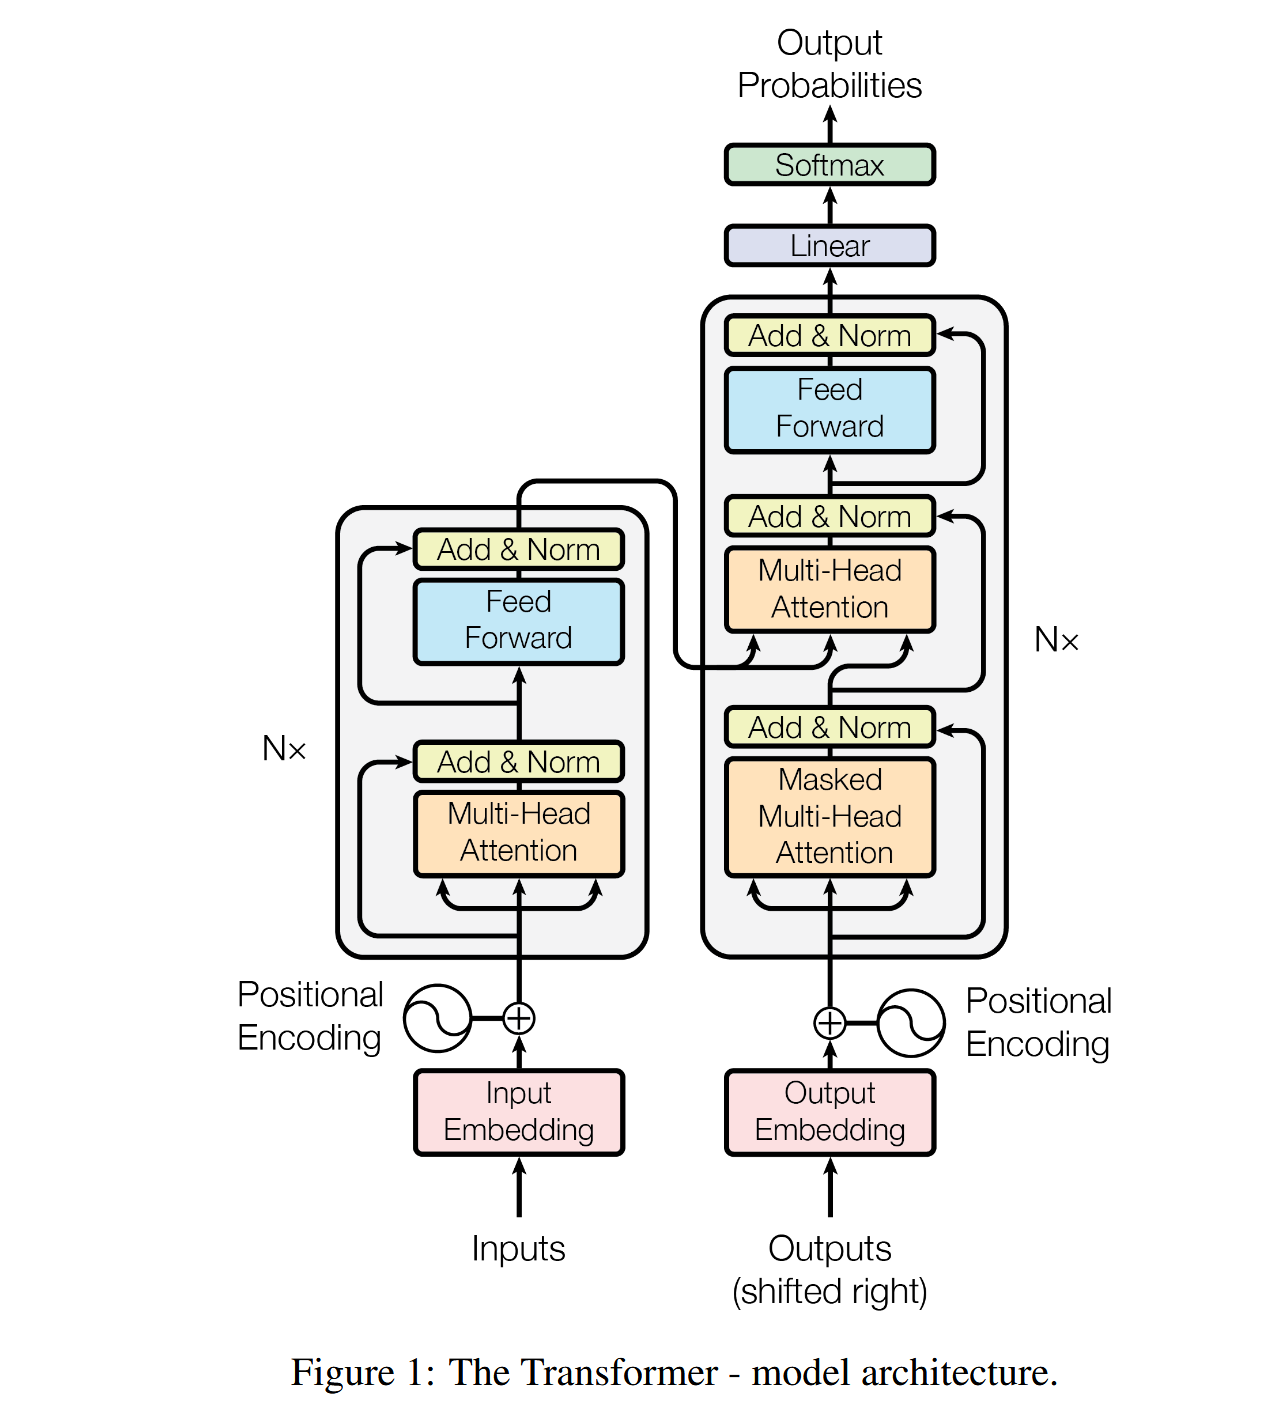

In [5]:
Image(filename='images/model_architecture.png')

### 编码器和解码器栈

#### 编码器

编码器由 N = 6 个layers组成 

In [6]:
def clones(module, N):
    "Produce N identical layers. "
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])


class Encoder(nn.Module):
    "Core encoder is a stack of N layers"
    def __init__(self, layer, N):
        super(Encoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)

    def forward(self, x, mask):
        "Pass the input (and mask) through each layer in turn."
        for layer in self.layers:
            x = layer(x, mask)

        return self.norm(x)

使用一个残差网络 + 归一化网络： We employ a residual connection (cite) around each of the two sub-layers, followed by layer normalization (cite).

In [7]:
class LayerNorm(nn.Module):
    ""
    def __init__(self, features, eps=1e-6):
        super(LayerNorm, self).__init__()
        self.a_2 = nn.Parameter(torch.ones(features))
        self.b_2 = nn.Parameter(torch.zeros(features))
        self.eps = eps
    
    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.a_2 * (x - mean) / (std + self.eps) + self.b_2


每一个子层输出的是 LayerNorm(x + Sublayer(x)). 并利用dropout作用于Sublayer.

To facilitate these residual connections, all sub-layers in the model, as well as the embedding layers, produce outputs of dimension d_{model} = 512

In [8]:
class SublayerConnection(nn.Module):
    """
    A residual connection followed by a layer norm.
    Note for code simplicity the norm is first as opposed to last.
    """
    def __init__(self, size, dropout):
        super(SublayerConnection, self).__init__()
        self.norm = LayerNorm(size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer):
        "Apply residual connection to any sublayer with the same size."
        return x + self.dropout(sublayer(self.norm(x)))

Each layer has two sub-layers. The first is a multi-head self-attention mechanism, and the second is a simple, position-wise fully connected feed- forward network.

每一层都有两个子层。第一层是多头自注意力机制，第二层是简单的、位置式全连接前馈网络。

In [9]:
class EncoderLayer(nn.Module):
    ""
    def __init__(self, size, self_attn, feed_forward, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = self_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 2)
        self.size = size

    def forward(self, x, mask):
        ""
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, mask))
        return self.sublayer[1](x, self.feed_forward)

### 解码器

The decoder is also composed of a stack of N = 6 identical layers.

In [10]:
class Decoder(nn.Module):
    "Generic N layer decoder with masking."
    def __init__(self, layer, N):
        super(Decoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)

    def forward(self, x, memory, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)

除了每个编码器层中的两个子层之外，解码器还插入了第三个子层，该子层对编码器堆栈的输出执行多头注意。与编码器类似，我们在每个子层周围采用残差连接，然后进行层规范化。

In [11]:
class DecoderLayer(nn.Module):
    "Decoder is made of self-attn, src-attn, and feed forward (defined below)"
    def __init__(self, size, self_attn, src_attn, feed_forward, dropout):
        super(DecoderLayer, self).__init__()
        self.size = size
        self.self_attn = self_attn
        self.src_attn = src_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 3)
   
    def forward(self, x, memory, src_mask, tgt_mask):
        "Follow Figure 1 (right) for connections."
        m = memory
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))
        x = self.sublayer[1](x, lambda x: self.src_attn(x, m, m, src_mask))
        return self.sublayer[2](x, self.feed_forward)


我们还修改了解码器堆栈中的自注意力子层，以防止位置关注后续位置。这种掩蔽与输出嵌入偏移一个位置的事实相结合，确保了位置的预测
i只能依赖于小于位置的已知输出i。

In [12]:
def subsequent_mask(size):
    "Mask out subsequent positions."
    attn_shape = (1, size, size)
    subsequent_mask = np.triu(np.ones(attn_shape), k =1).astype('uint8')
    return torch.from_numpy(subsequent_mask) == 0

注意力掩码下方显示了每个目标单词（行）允许查看的位置（列）。在训练期间，单词被阻止以关注未来的单词。

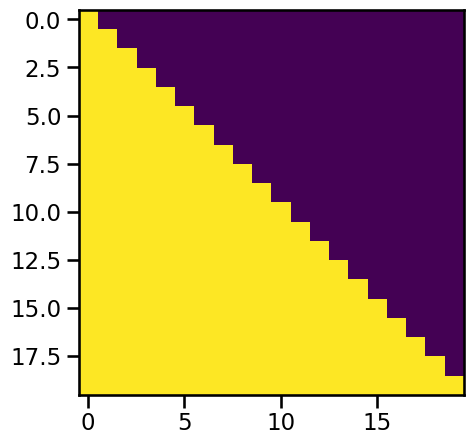

In [13]:
plt.figure(figsize=(5,5))
plt.imshow(subsequent_mask(20)[0])
# None

### 注意力
注意力函数可以描述为将查询和一组键值对映射到输出，其中查询、键、值和输出都是向量。输出计算为值的加权和，其中分配给每个值的权重由查询与相应键的兼容性函数计算得出。

We call our particular attention “Scaled Dot-Product Attention”. The input consists of queries and keys of dimension d_k, and values of dimension 
d_v. We compute the dot products of the query with all keys, divide each by √d_k, and apply a softmax function to obtain the weights on the values.

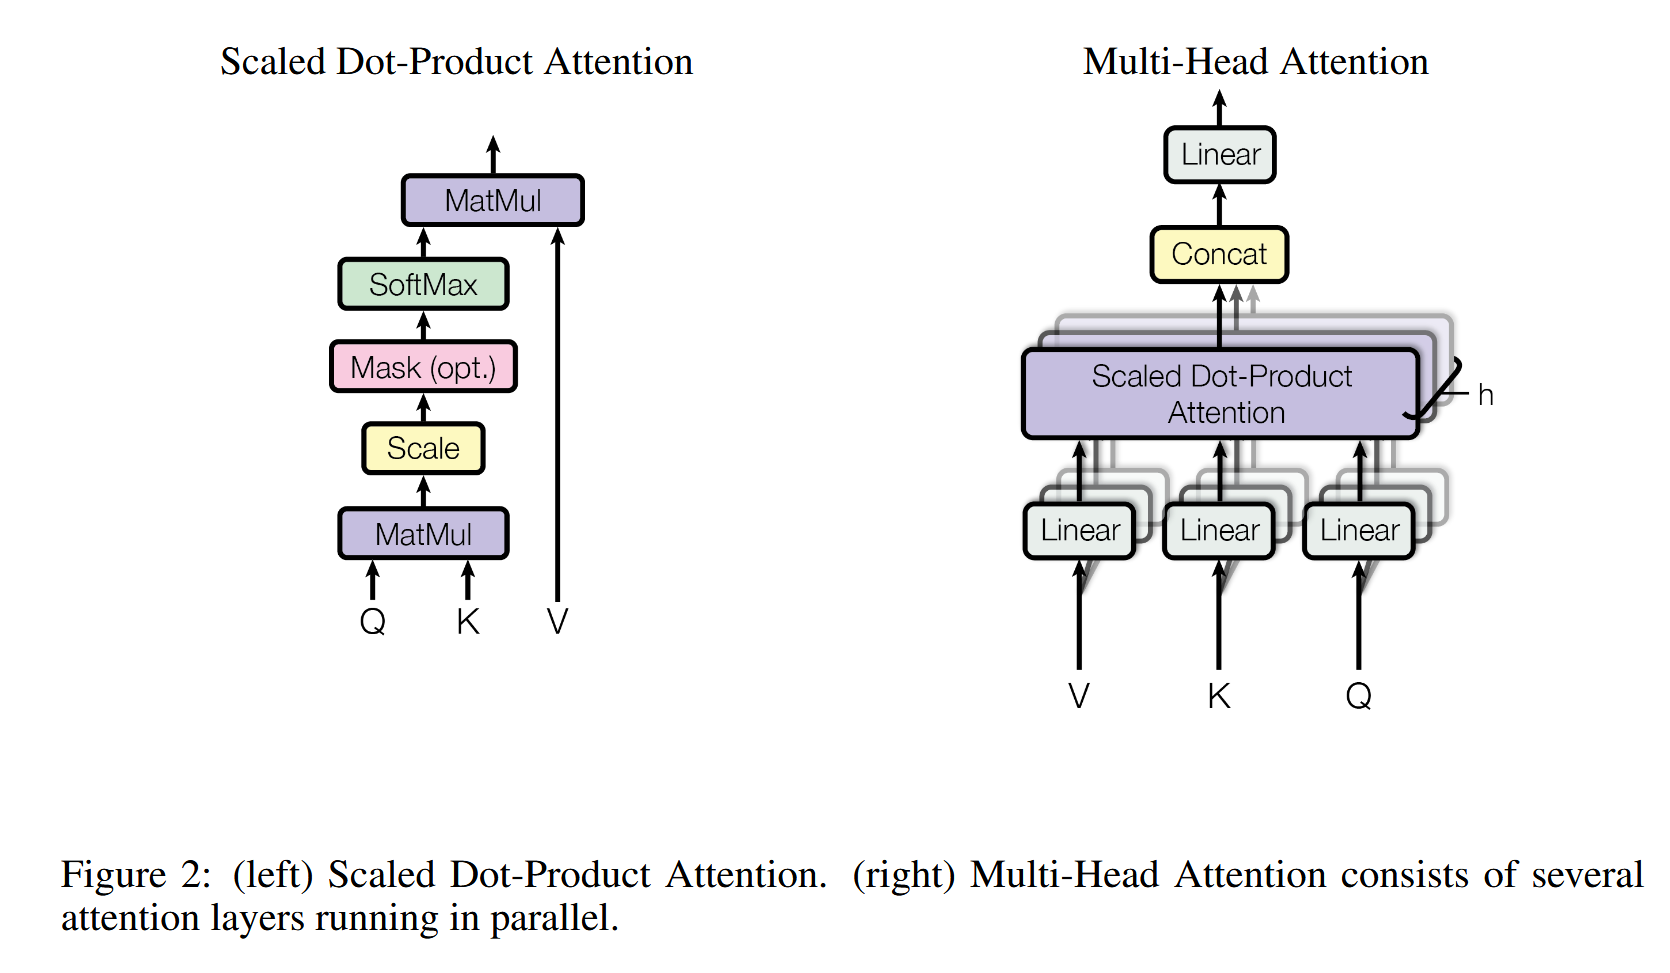

In [14]:
Image(filename='images/dot_product_and_multi-head_attenttion.png')

In practice, we compute the attention function on a set of queries simultaneously, packed together into a matrix 
Q. The keys and values are also packed together into matrices K and  V. We compute the matrix of outputs as:

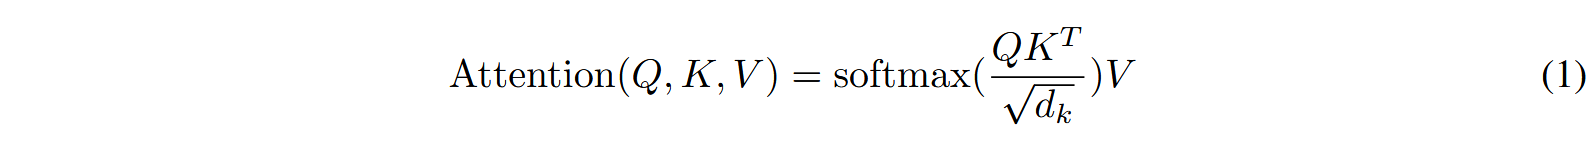

In [15]:
Image(filename='images/attention.png')

In [16]:
def attention(query, key, value, mask=None, dropout=None):
    ""
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1))  / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    
    p_attn = F.softmax(scores, dim = -1)
    
    if dropout is not None:
        p_attn = dropout(p_attn)

    return torch.matmul(p_attn, value), p_attn   

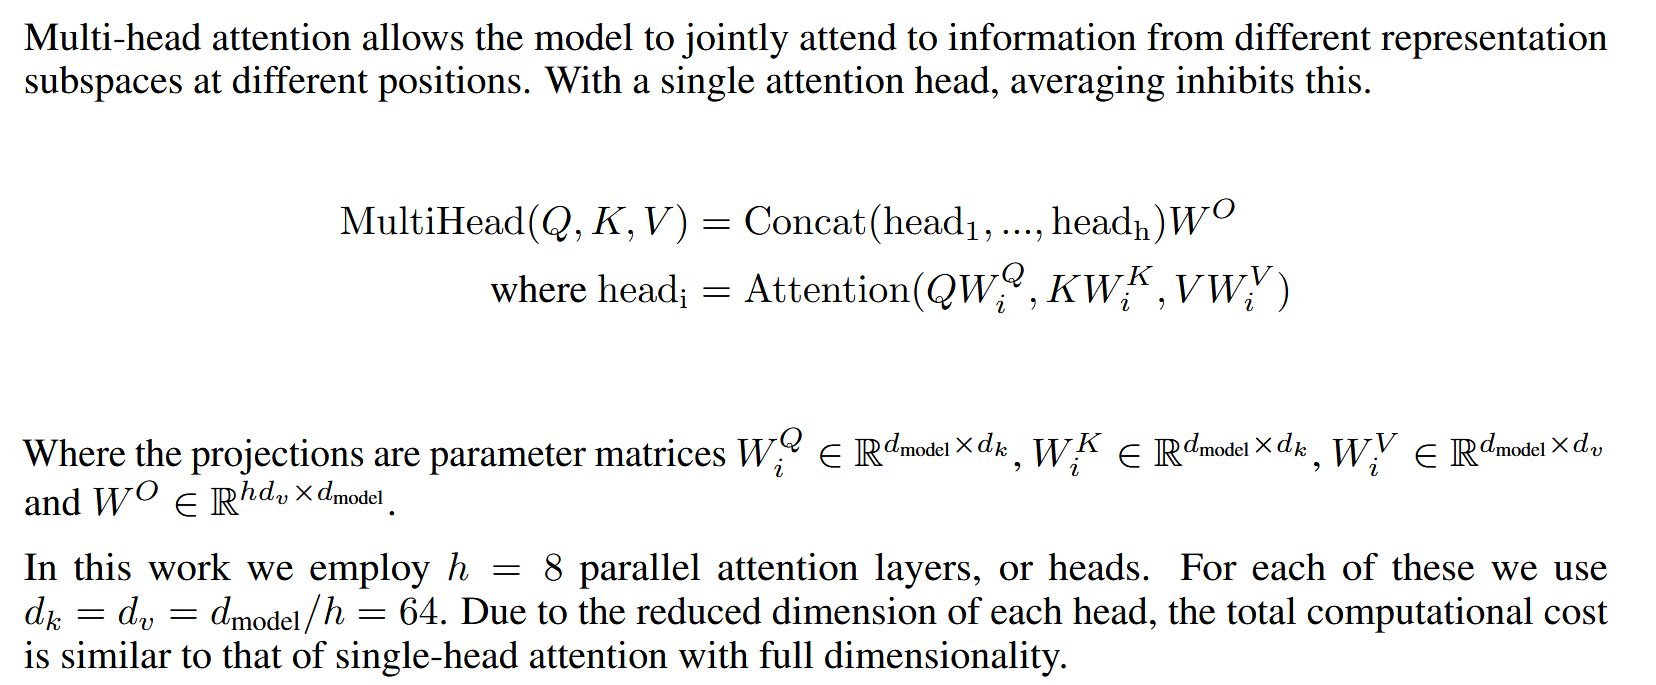

In [17]:
Image(filename='images/multi-head_attention.png')

In [18]:
class MultiHeadedAttention(nn.Module):
    def __init__(self, h, d_model, dropout=0.1):
        "Take in model size and number of heads."
        super(MultiHeadedAttention, self).__init__()
        assert d_model % h == 0
        # We assume d_v always equals d_k
        self.d_k = d_model // h
        self.h = h
        self.linears = clones(nn.Linear(d_model, d_model), 4)
        self.attn = None
        self.dropout = nn.Dropout(p=dropout)
        
    def forward(self, query, key, value, mask=None):
        "Implements Figure 2"
        if mask is not None:
            # Same mask applied to all h heads.
            mask = mask.unsqueeze(1)
        nbatches = query.size(0)
        
        # 1) Do all the linear projections in batch from d_model => h x d_k 
        query, key, value = \
            [l(x).view(nbatches, -1, self.h, self.d_k).transpose(1, 2)
             for l, x in zip(self.linears, (query, key, value))]
        
        # 2) Apply attention on all the projected vectors in batch. 
        x, self.attn = attention(query, key, value, mask=mask, 
                                 dropout=self.dropout)
        
        # 3) "Concat" using a view and apply a final linear. 
        x = x.transpose(1, 2).contiguous() \
             .view(nbatches, -1, self.h * self.d_k)
        return self.linears[-1](x)

### 注意力机制在我们模型中的应用

Transformer 以三种不同的方式使用多头注意力机制：
1) 在“编码器-解码器注意力”层中，查询来自前一个解码器层，记忆键和值来自编码器的输出。这允许解码器中的每个位置关注输入序列中的所有位置。这模仿了序列到序列模型中的典型编码器-解码器注意力机制，例如 （引用）。

2) 编码器包含自注意力层。在自注意力层中，所有键、值和查询都来自同一位置，在本例中，即编码器中上一层的输出。编码器中的每个位置都可以关注编码器上一层的所有位置。

3) 类似地，解码器中的自注意力层允许解码器中的每个位置关注解码器中直到该位置的所有位置。我们需要防止解码器中的左向信息流以保留自回归属性。我们在缩放点积注意力中通过屏蔽（设置为-∞) softmax 输入中与非法连接相对应的所有值。

#### 位置前馈网络

除了注意力子层之外，我们的编码器和解码器中的每一层都包含一个完全连接的前馈网络，该网络分别且相同地应用于每个位置。它由两个线性变换组成，中间有一个 ReLU 激活。

虽然线性变换在不同位置上是相同的，但它们在层与层之间使用不同的参数。另一种描述方式是将其描述为两个内核大小为 1 的卷积。输入和输出的维数为d_model = 512，内层具有维度d_ff = 2048。

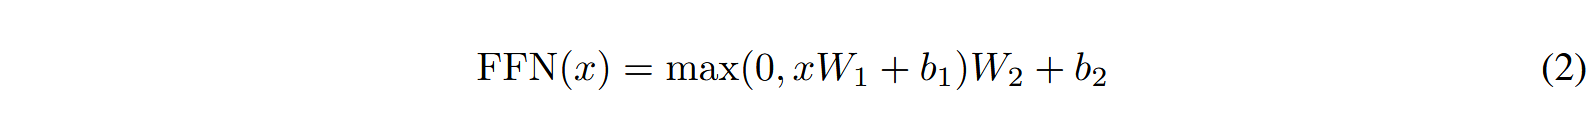

In [19]:
Image(filename='images/position-wise_FFN.png')

In [20]:
class PositionwiseFeedForward(nn.Module):
    "Implements FFN equation."
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(F.relu(self.w_1(x))))

#### Embedding and Softmax

与其他序列传导模型类似，我们使用学习到的嵌入将输入标记和输出标记转换为维度向量 d_model。我们还使用通常学习的线性变换和 softmax 函数将解码器输出转换为预测的下一个标记概率。在我们的模型中，我们在两个嵌入层和预 softmax 线性变换之间共享相同的权重矩阵，类似于 （引用）。在嵌入层中，我们将这些权重乘以√d_model。

In [21]:
class Embeddings(nn.Module):
    def __init__(self, d_model, vocab):
        super(Embeddings, self).__init__()
        self.lut = nn.Embedding(vocab, d_model)
        self.d_model = d_model

    def forward(self, x):
        return self.lut(x) * math.sqrt(self.d_model)

#### 位置编码

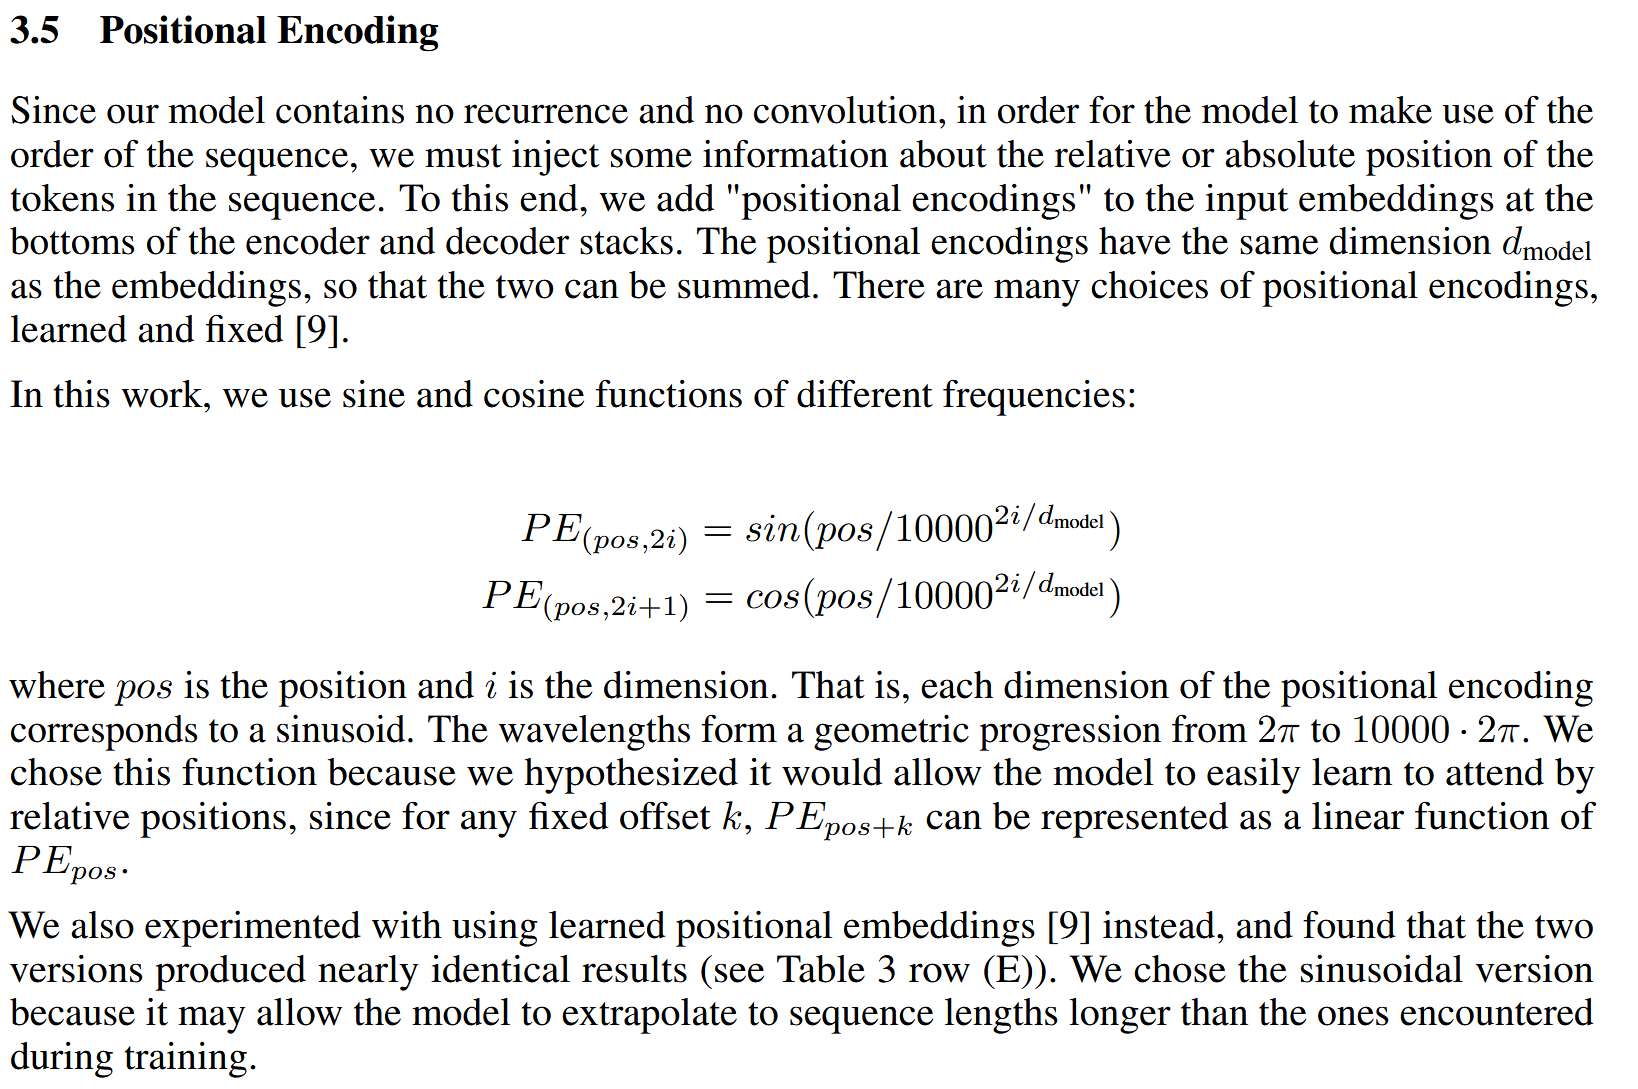

In [22]:
Image(filename='images/positional_encoding.png')

由于我们的模型不包含循环和卷积，为了让模型利用序列的顺序，我们必须注入一些关于序列中标记的相对或绝对位置的信息。为此，我们在编码器和解码器堆栈底部的输入嵌入中添加了“位置编码”。位置编码具有相同的维度 
d_model作为嵌入，这样两者就可以相加了。位置编码有很多种选择，学习的和固定的 （引用）。

In [23]:
class PositionalEncoding(nn.Module):
    "Implement the PE function."
    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Compute the positional encodings once in log space.
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) *
                             -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + Variable(self.pe[:, :x.size(1)], 
                         requires_grad=False)
        return self.dropout(x)

**位置编码下方会根据位置添加一个正弦波。波的频率和偏移量对于每个维度都是不同的。**

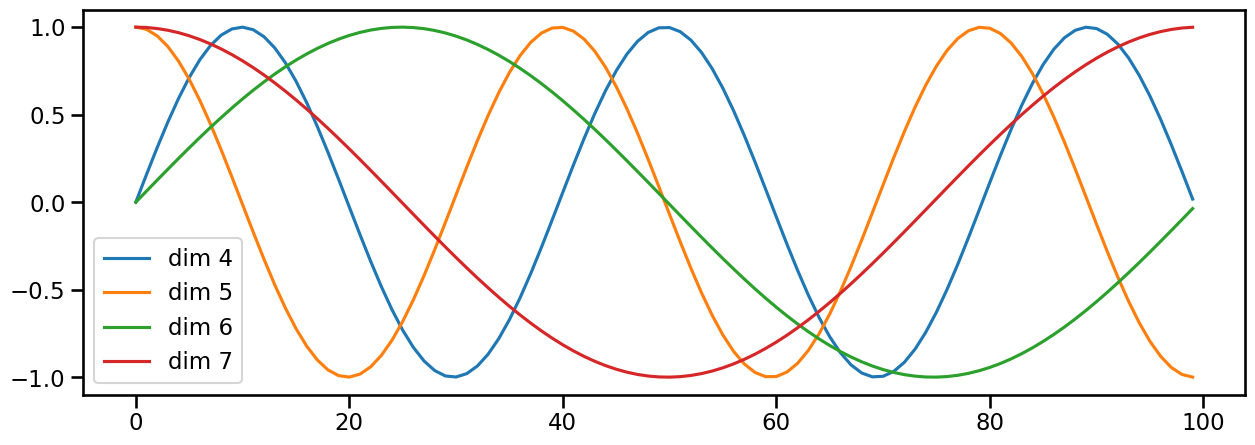

In [24]:
plt.figure(figsize=(15, 5))
pe = PositionalEncoding(20, 0)
y = pe.forward(Variable(torch.zeros(1, 100, 20)))
plt.plot(np.arange(100), y[0, :, 4:8].data.numpy())
plt.legend(["dim %d"%p for p in [4,5,6,7]])
None

我们还尝试使用学习到的位置嵌入 （cite），发现两个版本产生的结果几乎相同。我们选择正弦版本，因为它可能允许模型推断出比训练期间遇到的序列长度更长的序列长度。

### 完整模型

In [25]:
def make_model(src_vocab, tgt_vocab, N=6, 
               d_model=512, d_ff=2048, h=8, dropout=0.1):
    "Helper: Construct a model from hyperparameters."
    c = copy.deepcopy
    attn = MultiHeadedAttention(h, d_model)
    ff = PositionwiseFeedForward(d_model, d_ff, dropout)
    position = PositionalEncoding(d_model, dropout)
    model = EncoderDecoder(
        Encoder(EncoderLayer(d_model, c(attn), c(ff), dropout), N),
        Decoder(DecoderLayer(d_model, c(attn), c(attn), 
                             c(ff), dropout), N),
        nn.Sequential(Embeddings(d_model, src_vocab), c(position)),
        nn.Sequential(Embeddings(d_model, tgt_vocab), c(position)),
        Generator(d_model, tgt_vocab))
    
    # This was important from their code. 
    # Initialize parameters with Glorot / fan_avg.
    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform(p)
    return model

In [26]:
# Small example model.
tmp_model = make_model(10, 10, 2)
None

C:\Users\sheng.daolin\AppData\Local\Temp\ipykernel_30692\2289673833.py:20: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  nn.init.xavier_uniform(p)


#### 训练

- 1，我们先简短地介绍一下训练标准编码器解码器模型所需的一些工具。首先，我们定义一个批处理对象，其中包含用于训练的源句子和目标句子，以及构建掩码。
- 2，接下来，我们创建一个通用的训练和评分函数来跟踪损失。我们传入一个通用的损失计算函数，该函数还处理参数更新
- 3，我们将使用 torch text 进行批处理。下面将对此进行更详细的讨论。在这里，我们在 torchtext 函数中创建批处理，以确保填充到最大批处理大小的批处理大小不超过阈值（如果我们有 8 个 gpu，则为 25000）

#### 批次和掩码

In [27]:
class Batch:
    "Object for holding a batch of data with mask during training."
    def __init__(self, src, trg=None, pad=0):
        self.src = src
        self.src_mask = (src != pad).unsqueeze(-2)
        if trg is not None:
            self.trg = trg[:, :-1]
            self.trg_y = trg[:, 1:]
            self.trg_mask = \
                self.make_std_mask(self.trg, pad)
            self.ntokens = (self.trg_y != pad).data.sum()
    
    @staticmethod
    def make_std_mask(tgt, pad):
        "Create a mask to hide padding and future words."
        tgt_mask = (tgt != pad).unsqueeze(-2)
        tgt_mask = tgt_mask & Variable(
            subsequent_mask(tgt.size(-1)).type_as(tgt_mask.data))
        return tgt_mask

#### 训练循环

In [28]:
def run_epoch(data_iter, model, loss_compute):
    "Standard Training and Logging Function"
    start = time.time()
    total_tokens = 0
    total_loss = 0
    tokens = 0
    for i, batch in enumerate(data_iter):
        out = model.forward(batch.src, batch.trg, 
                            batch.src_mask, batch.trg_mask)
        loss = loss_compute(out, batch.trg_y, batch.ntokens)
        total_loss += loss
        total_tokens += batch.ntokens
        tokens += batch.ntokens
        if i % 50 == 1:
            elapsed = time.time() - start
            print("Epoch Step: %d Loss: %f Tokens per Sec: %f" %
                    (i, loss / batch.ntokens, tokens / elapsed))
            start = time.time()
            tokens = 0
    return total_loss / total_tokens

#### 训练数据和批处理

我们在包含约 450 万个句子对的标准 WMT 2014 英德数据集上进行训练。句子使用字节对编码进行编码，该编码具有约 37000 个标记的源目标共享词汇表。对于英语-法语，我们使用了更大的 WMT 2014 英法数据集，该数据集包含 3600 万个句子并将标记拆分为 32000 个单词词汇表。

句子对按近似序列长度分批。每个训练批次包含一组句子对，其中包含大约 25000 个源标记和 25000 个目标标记。

In [29]:
global max_src_in_batch, max_tgt_in_batch
def batch_size_fn(new, count, sofar):
    "Keep augmenting batch and calculate total number of tokens + padding."
    global max_src_in_batch, max_tgt_in_batch
    if count == 1:
        max_src_in_batch = 0
        max_tgt_in_batch = 0
    max_src_in_batch = max(max_src_in_batch,  len(new.src))
    max_tgt_in_batch = max(max_tgt_in_batch,  len(new.trg) + 2)
    src_elements = count * max_src_in_batch
    tgt_elements = count * max_tgt_in_batch
    return max(src_elements, tgt_elements)

#### 硬件和时间表

我们在一台配备 8 个 NVIDIA P100 GPU 的机器上训练了我们的模型。对于使用本文所述超参数的基础模型，每个训练步骤大约需要 0.4 秒。我们对基础模型进行了总共 100,000 步或 12 小时的训练。对于我们的大模型，步骤时间为 1.0 秒。大模型的训练时间为 300,000 步（3.5 天）。

**注意：这部分非常重要。需要使用此模型设置进行训练。**

In [30]:
class NoamOpt:
    "Optim wrapper that implements rate."
    def __init__(self, model_size, factor, warmup, optimizer):
        self.optimizer = optimizer
        self._step = 0
        self.warmup = warmup
        self.factor = factor
        self.model_size = model_size
        self._rate = 0
        
    def step(self):
        "Update parameters and rate"
        self._step += 1
        rate = self.rate()
        for p in self.optimizer.param_groups:
            p['lr'] = rate
        self._rate = rate
        self.optimizer.step()
        
    def rate(self, step = None):
        "Implement `lrate` above"
        if step is None:
            step = self._step
        return self.factor * \
            (self.model_size ** (-0.5) *
            min(step ** (-0.5), step * self.warmup ** (-1.5)))
        
def get_std_opt(model):
    return NoamOpt(model.src_embed[0].d_model, 2, 4000,
            torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9))

**该模型针对不同模型大小和优化超参数的曲线示例。**

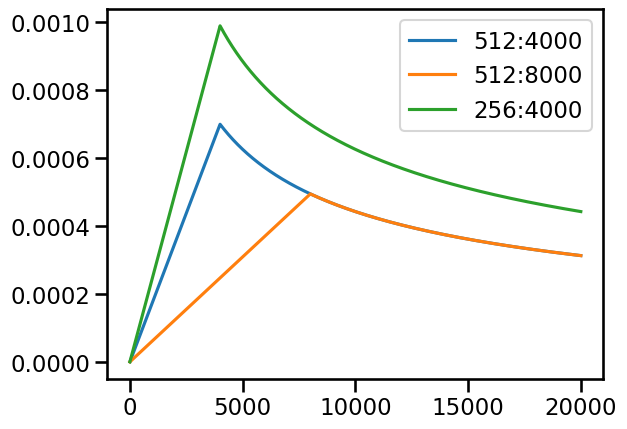

In [31]:
# Three settings of the lrate hyperparameters.
opts = [NoamOpt(512, 1, 4000, None), 
        NoamOpt(512, 1, 8000, None),
        NoamOpt(256, 1, 4000, None)]
plt.plot(np.arange(1, 20000), [[opt.rate(i) for opt in opts] for i in range(1, 20000)])
plt.legend(["512:4000", "512:8000", "256:4000"])
None

#### 正则化

##### 标签平滑

During training, we employed label smoothing of value ϵls = 0.1 (cite). This hurts perplexity, as the model learns to be more unsure, but improves accuracy and BLEU score.

我们使用 KL div 损失来实现标签平滑。我们不使用独热目标分布，而是创建一个分布，其中包含正确单词和词汇表中confidence其余部分的质量。smoothing

In [32]:
class LabelSmoothing(nn.Module):
    "Implement label smoothing."
    def __init__(self, size, padding_idx, smoothing=0.0):
        super(LabelSmoothing, self).__init__()
        self.criterion = nn.KLDivLoss(size_average=False)
        self.padding_idx = padding_idx
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.size = size
        self.true_dist = None
        
    def forward(self, x, target):
        assert x.size(1) == self.size
        true_dist = x.data.clone()
        true_dist.fill_(self.smoothing / (self.size - 2))
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        true_dist[:, self.padding_idx] = 0
        mask = torch.nonzero(target.data == self.padding_idx)
        if mask.dim() > 0:
            true_dist.index_fill_(0, mask.squeeze(), 0.0)
        self.true_dist = true_dist
        return self.criterion(x, Variable(true_dist, requires_grad=False))

这里我们可以看到如何根据置信度将质量分配给单词的一个例子。

D:\installs\Miniconda3\envs\transformer_learning\lib\site-packages\torch\nn\_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))


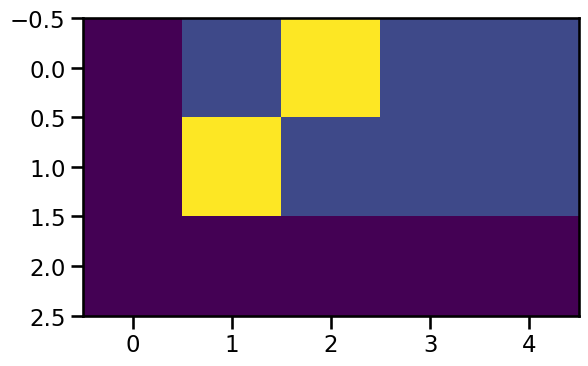

In [33]:
# Example of label smoothing.
crit = LabelSmoothing(5, 0, 0.4)
predict = torch.FloatTensor([[0, 0.2, 0.7, 0.1, 0],
                             [0, 0.2, 0.7, 0.1, 0], 
                             [0, 0.2, 0.7, 0.1, 0]])
v = crit(Variable(predict.log()), 
         Variable(torch.LongTensor([2, 1, 0])))

# Show the target distributions expected by the system.
plt.imshow(crit.true_dist)
None

如果标签平滑对给定的选择非常有信心，它实际上会开始惩罚模型。

In [34]:
# crit = LabelSmoothing(5, 0, 0.1)
# def loss(x):
#     d = x + 3 * 1
#     predict = torch.FloatTensor([[0, x / d, 1 / d, 1 / d, 1 / d],
#                                  ])
#     print(predict)
#     return crit(Variable(predict.log()),
#                  Variable(torch.LongTensor([1]))).data[0]
# plt.plot(np.arange(1, 100), [loss(x) for x in range(1, 100)])
# None

### 第一个例子
我们可以从尝试一个简单的复制任务开始。给定一组来自​​小词汇表的随机输入符号，目标是生成相同的符号。

#### 合成数据

In [35]:
def data_gen(V, batch, nbatches):
    "Generate random data for a src-tgt copy task."
    for i in range(nbatches):
        data = torch.from_numpy(np.random.randint(1, V, size=(batch, 10)))
        data[:, 0] = 1
        src = Variable(data, requires_grad=False)
        tgt = Variable(data, requires_grad=False)
        yield Batch(src, tgt, 0)

In [36]:
# 损失计算
class SimpleLossCompute:
    "A simple loss compute and train function."
    def __init__(self, generator, criterion, opt=None):
        self.generator = generator
        self.criterion = criterion
        self.opt = opt
        
    def __call__(self, x, y, norm):
        x = self.generator(x)
        loss = self.criterion(x.contiguous().view(-1, x.size(-1)), 
                              y.contiguous().view(-1)) / norm
        loss.backward()
        if self.opt is not None:
            self.opt.step()
            self.opt.optimizer.zero_grad()
        return loss.data[0] * norm

In [37]:
# 贪婪解码
# Train the simple copy task.
# V = 11
# criterion = LabelSmoothing(size=V, padding_idx=0, smoothing=0.0)
# model = make_model(V, V, N=2)
# model_opt = NoamOpt(model.src_embed[0].d_model, 1, 400,
#         torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9))

# for epoch in range(10):
#     model.train()
#     run_epoch(data_gen(V, 30, 20), model, 
#               SimpleLossCompute(model.generator, criterion, model_opt))
#     model.eval()
#     print(run_epoch(data_gen(V, 30, 5), model, 
#                     SimpleLossCompute(model.generator, criterion, None)))


In [38]:
# 为了简单起见，此代码使用贪婪解码来预测翻译。
def greedy_decode(model, src, src_mask, max_len, start_symbol):
    memory = model.encode(src, src_mask)
    ys = torch.ones(1, 1).fill_(start_symbol).type_as(src.data)
    for i in range(max_len-1):
        out = model.decode(memory, src_mask, 
                           Variable(ys), 
                           Variable(subsequent_mask(ys.size(1))
                                    .type_as(src.data)))
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim = 1)
        next_word = next_word.data[0]
        ys = torch.cat([ys, 
                        torch.ones(1, 1).type_as(src.data).fill_(next_word)], dim=1)
    return ys

model.eval()
src = Variable(torch.LongTensor([[1,2,3,4,5,6,7,8,9,10]]) )
src_mask = Variable(torch.ones(1, 1, 10) )
print(greedy_decode(model, src, src_mask, max_len=10, start_symbol=1))

NameError: name 'model' is not defined